# HCC Proteomics (Normal) - Data Understanding

This notebook performs the initial exploration of the public HCC
proteomics dataset.

Objectives:

- Load the dataset
- Verify its structure
- Assess data quality
- Identify missing values
- Understand variables before preprocessing

In [4]:
import pandas as pd
import sys
print(sys.executable)

c:\Users\lebar0040\OneDrive - University of Bergen\ai-analytics-agent\.venv\Scripts\python.exe


In [5]:
import pandas as pd

print(pd.__version__)

3.0.5


In [6]:
import pandas as pd

file_path = "../data/raw/HCC_proteomics_Normal.txt"

df = pd.read_csv(file_path, sep="\t")

print(df.shape)
df.head()

(11175, 166)


,idx,111,114,124,126,128,132,136,138,142,...,1022,1026,1028,1032,1042,1044,1046,448,536,698
0,ENSG00000000003.15,25.123487,24.792504,24.813667,24.556260,24.454895,24.808779,25.026977,24.389151,24.473884,...,24.755773,24.407858,24.315442,24.453317,24.396582,24.540703,24.918928,24.876518,24.128921,24.552410
1,ENSG00000000419.12,26.441628,26.253745,26.372726,26.092552,26.482692,26.311869,26.234817,26.126119,26.158555,...,26.125231,26.021210,25.968990,26.313476,25.965280,26.123274,26.109980,26.063115,25.605649,26.076056
2,ENSG00000000457.14,23.319190,23.337303,23.175404,23.405809,23.226412,23.402456,23.529123,23.450332,23.286908,...,23.176737,23.071129,23.280037,23.063194,22.999710,23.304137,23.404143,22.993107,22.830460,22.914256
3,ENSG00000000460.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENSG00000000938.13,21.392391,21.425340,21.522826,21.598335,21.432756,21.201646,21.367521,21.457526,21.352120,...,20.830519,21.417127,21.410856,20.710182,20.860214,21.412469,21.509806,21.002283,21.438820,21.669404


In [7]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("\nFirst five rows")
display(df.head())

DATASET SHAPE
(11175, 166)

First five rows


,idx,111,114,124,126,128,132,136,138,142,...,1022,1026,1028,1032,1042,1044,1046,448,536,698
0,ENSG00000000003.15,25.123487,24.792504,24.813667,24.556260,24.454895,24.808779,25.026977,24.389151,24.473884,...,24.755773,24.407858,24.315442,24.453317,24.396582,24.540703,24.918928,24.876518,24.128921,24.552410
1,ENSG00000000419.12,26.441628,26.253745,26.372726,26.092552,26.482692,26.311869,26.234817,26.126119,26.158555,...,26.125231,26.021210,25.968990,26.313476,25.965280,26.123274,26.109980,26.063115,25.605649,26.076056
2,ENSG00000000457.14,23.319190,23.337303,23.175404,23.405809,23.226412,23.402456,23.529123,23.450332,23.286908,...,23.176737,23.071129,23.280037,23.063194,22.999710,23.304137,23.404143,22.993107,22.830460,22.914256
3,ENSG00000000460.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENSG00000000938.13,21.392391,21.425340,21.522826,21.598335,21.432756,21.201646,21.367521,21.457526,21.352120,...,20.830519,21.417127,21.410856,20.710182,20.860214,21.412469,21.509806,21.002283,21.438820,21.669404


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11175 entries, 0 to 11174
Columns: 166 entries, idx to 698
dtypes: float64(165), str(1)
memory usage: 14.2 MB


In [9]:
print(df.columns.tolist())

['idx', '111', '114', '124', '126', '128', '132', '136', '138', '142', '146', '148', '162', '172', '186', '188', '192', '196', '214', '218', '222', '232', '258', '262', '268', '272', '278', '298', '312', '314', '332', '342', '344', '352', '354', '358', '362', '366', '368', '376', '384', '386', '388', '392', '394', '396', '414', '422', '424', '426', '428', '432', '434', '436', '444', '446', '452', '456', '464', '466', '468', '212', '224', '228', '284', '286', '328', '356', '364', '412', '416', '462', '472', '474', '478', '482', '484', '488', '492', '494', '498', '514', '516', '518', '524', '526', '528', '534', '538', '546', '554', '558', '564', '568', '572', '574', '616', '618', '628', '636', '642', '648', '662', '664', '666', '672', '686', '696', '714', '716', '722', '723', '728', '738', '742', '744', '746', '756', '778', '786', '814', '816', '818', '824', '852', '858', '862', '864', '866', '868', '874', '878', '882', '884', '912', '914', '916', '918', '922', '924', '926', '938', '944'

In [10]:
print(df["idx"].head())

print()

print("Unique IDs:", df["idx"].nunique())
print("Total rows:", len(df))

0    ENSG00000000003.15
1    ENSG00000000419.12
2    ENSG00000000457.14
3    ENSG00000000460.17
4    ENSG00000000938.13
Name: idx, dtype: str

Unique IDs: 11175
Total rows: 11175


In [11]:
### missing values
missing = df.isna().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False).head(20)

222    2535
214    2532
218    2531
192    2531
196    2530
126    2509
128    2506
124    2506
111    2505
114    2503
636    2478
642    2476
628    2474
618    2474
616    2473
352    2446
358    2446
344    2444
138    2444
132    2443
dtype: int64

In [12]:
## missing values percentage

missing_percent = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_percent.head(20)

222    22.684564
214    22.657718
192    22.648770
218    22.648770
196    22.639821
126    22.451902
124    22.425056
128    22.425056
111    22.416107
114    22.398210
636    22.174497
642    22.156600
618    22.138702
628    22.138702
616    22.129754
352    21.888143
358    21.888143
344    21.870246
138    21.870246
132    21.861298
dtype: float64

In [13]:
## summary statistics

df.describe()

,111,114,124,126,128,132,136,138,142,146,...,1022,1026,1028,1032,1042,1044,1046,448,536,698
count,8670.000000,8672.000000,8669.000000,8666.000000,8669.000000,8732.000000,8732.000000,8731.000000,8733.000000,8733.000000,...,9010.000000,9011.000000,9010.000000,9009.000000,9008.000000,9066.000000,9064.000000,9064.000000,9059.000000,9054.000000
mean,23.858160,23.853598,23.866697,23.872179,23.863498,23.837760,23.826634,23.828724,23.825237,23.830519,...,23.666691,23.659999,23.661083,23.664460,23.656674,23.635016,23.639156,23.648496,23.684398,23.657530
std,2.869058,2.863486,2.821623,2.808509,2.912270,2.859708,2.852409,2.835807,2.884074,2.825104,...,3.048552,3.049901,3.037528,3.043773,2.994959,3.022267,3.049635,3.066697,2.955848,3.027742
min,9.685361,9.877789,10.070910,10.066463,10.459032,11.223116,11.255782,11.547684,11.116056,11.128154,...,10.331326,10.152054,9.927638,10.462858,10.481052,10.185463,10.422436,10.417869,10.127108,10.855571
25%,21.997307,22.004389,22.058020,22.078812,21.983748,21.999665,21.992675,22.011216,21.976435,22.039743,...,21.748507,21.732356,21.741016,21.726042,21.793930,21.745427,21.718911,21.719338,21.852439,21.760075
50%,23.840437,23.843086,23.873074,23.883302,23.835309,23.832932,23.824058,23.835608,23.832862,23.832353,...,23.713177,23.703678,23.743504,23.711417,23.704810,23.668162,23.658193,23.682329,23.770806,23.663658
75%,25.780544,25.754899,25.742327,25.754783,25.778841,25.746283,25.753348,25.737348,25.759505,25.727313,...,25.722389,25.723028,25.732184,25.735753,25.691018,25.671582,25.695159,25.730866,25.726028,25.700564
max,32.335474,32.461641,31.805041,31.860927,32.999716,32.477917,32.167837,32.067968,32.100775,31.860826,...,32.804681,32.852873,32.182494,32.700838,32.198279,32.329801,32.491527,32.615617,31.843134,33.089766


In [14]:
import numpy as np

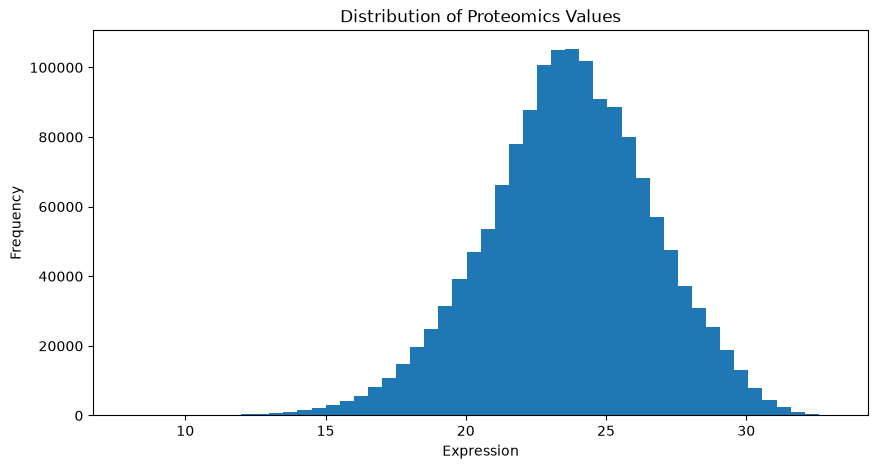

In [15]:
## Distribution

import matplotlib.pyplot as plt

values = df.iloc[:, 1:].values.flatten()

values = values[~np.isnan(values)]

plt.figure(figsize=(10,5))
plt.hist(values, bins=50)
plt.title("Distribution of Proteomics Values")
plt.xlabel("Expression")
plt.ylabel("Frequency")
plt.show()

### data quality checker

In [ ]:
import pandas as pd

def data_quality_report(df, id_column="idx"):
    """
    Generate a data quality report for an omics dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Omics data with one identifier column and sample columns.

    id_column : str
        Name of the identifier column.

    Returns
    -------
    pandas.DataFrame
        Data quality summary.
    """

    sample_df = df.drop(columns=[id_column])

    report = pd.DataFrame({
        "Metric": [
            "Number of features",
            "Number of samples",
            "Duplicate identifiers",
            "Duplicate sample names",
            "Total missing values",
            "Missing percentage (%)",
            "Minimum value",
            "Maximum value",
            "Mean value",
            "Median value",
            "Standard deviation"
        ],
        "Value": [
            df.shape[0],
            sample_df.shape[1],
            df[id_column].duplicated().sum(),
            sample_df.columns.duplicated().sum(),
            sample_df.isna().sum().sum(),
            round(sample_df.isna().sum().sum() /
                  sample_df.size * 100, 3),
            sample_df.min().min(),
            sample_df.max().max(),
            round(sample_df.stack().mean(), 3),
            round(sample_df.stack().median(), 3),
            round(sample_df.stack().std(), 3)
        ]
    })

    return report

In [17]:
report = data_quality_report(df)

report

,Metric,Value
0,Number of features,11175.000000
1,Number of samples,165.000000
2,Duplicate identifiers,0.000000
3,Duplicate sample names,0.000000
4,Total missing values,355699.000000
5,Missing percentage (%),19.291000
6,Minimum value,7.971212
7,Maximum value,33.089766
8,Mean value,23.663000
9,Median value,23.714000
